In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

In [28]:
signal = torch.from_numpy(np.loadtxt("../sample_data/CresolRed_after_styrene_600MHz.csv")[:,1]).float()
signal /= signal.max()  # Normalize to [0, 1]

In [29]:
def beta_from_H(H, target_value=0.5):
    """
    Compute beta for a given H such that the sigmoid function maps H to target_value.
    """
    return - math.log(2/(1+target_value) -1)/ H

class MultiscaleFeatureExtractor:
    """
    Extracts multiscale features from 1D signals using sigmoid-based transformations.
    
    Parameters:
    -----------
    H_0 : float
        Base length scale
    lambda_scale : float
        Scaling factor for successive length scales (H_{i+1} = lambda * H_i)
    k : int
        Number of feature scales to extract
    target_value : float
        Target value for sigmoid at H_0 (default: 0.5)
    """
    def __init__(self, H_0, lambda_scale, k, target_value=0.5):
        self.H_0 = H_0
        self.lambda_scale = lambda_scale
        self.k = k
        self.target_value = target_value
        
        self.beta_0 = beta_from_H(H_0, target_value)

        # Compute all betas and H values
        self.betas = []
        self.H_values = []
        for i in range(k):
            H_i = H_0 * (lambda_scale ** i)
            beta_i = beta_from_H(H_i, target_value)
            self.betas.append(beta_i)
            self.H_values.append(H_i)
    
    def extract_features(self, x):
        """
        Extract multiscale features from input signal batch.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input signal batch of shape (batch_size, 1, length)
        
        Returns:
        --------
        features : torch.Tensor
            Multiscale features of shape (batch_size, k, length)
        """
        # Ensure input has correct shape (batch_size, 1, length)
        if x.dim() == 2:
            x = x.unsqueeze(1)  # (batch_size, length) -> (batch_size, 1, length)
        elif x.dim() == 1:
            x = x.unsqueeze(0).unsqueeze(0)  # (length,) -> (1, 1, length)
        
        # Squeeze out the channel dimension for processing
        x = x.squeeze(1)  # (batch_size, 1, length) -> (batch_size, length)
        
        features = []
        for beta_i in self.betas:
            # Apply: 2*sigmoid(beta_i * x) - 1
            feature_i = 2 * torch.sigmoid(beta_i * x) - 1
            features.append(feature_i)
        
        # Stack along channel dimension: (k, batch_size, length) -> (batch_size, k, length)
        features = torch.stack(features, dim=0)  # (k, batch_size, length)
        features = features.permute(1, 0, 2)  # (batch_size, k, length)
        
        return features
    
    def __repr__(self):
        info = f"MultiscaleFeatureExtractor(\n"
        info += f"  H_0={self.H_0:.4f}, lambda={self.lambda_scale:.4f}, k={self.k}\n"
        info += f"  beta_0={self.beta_0:.4f}, target_value={self.target_value}\n"
        info += f"  Length scales: {[f'{h:.4f}' for h in self.H_values]}\n"
        info += f"  Beta values: {[f'{b:.4f}' for b in self.betas]}\n"
        info += f")"
        return info

In [30]:
x = signal.unsqueeze(0).unsqueeze(0)  # (1, 1, length)

MultiscaleFeatureExtractor(
  H_0=0.5000, lambda=0.5000, k=10
  beta_0=2.1972, target_value=0.5
  Length scales: ['0.5000', '0.2500', '0.1250', '0.0625', '0.0312', '0.0156', '0.0078', '0.0039', '0.0020', '0.0010']
  Beta values: ['2.1972', '4.3944', '8.7889', '17.5778', '35.1556', '70.3112', '140.6224', '281.2448', '562.4895', '1124.9790']
)

Input shape: torch.Size([1, 1, 32768])
Output shape: torch.Size([1, 10, 32768])


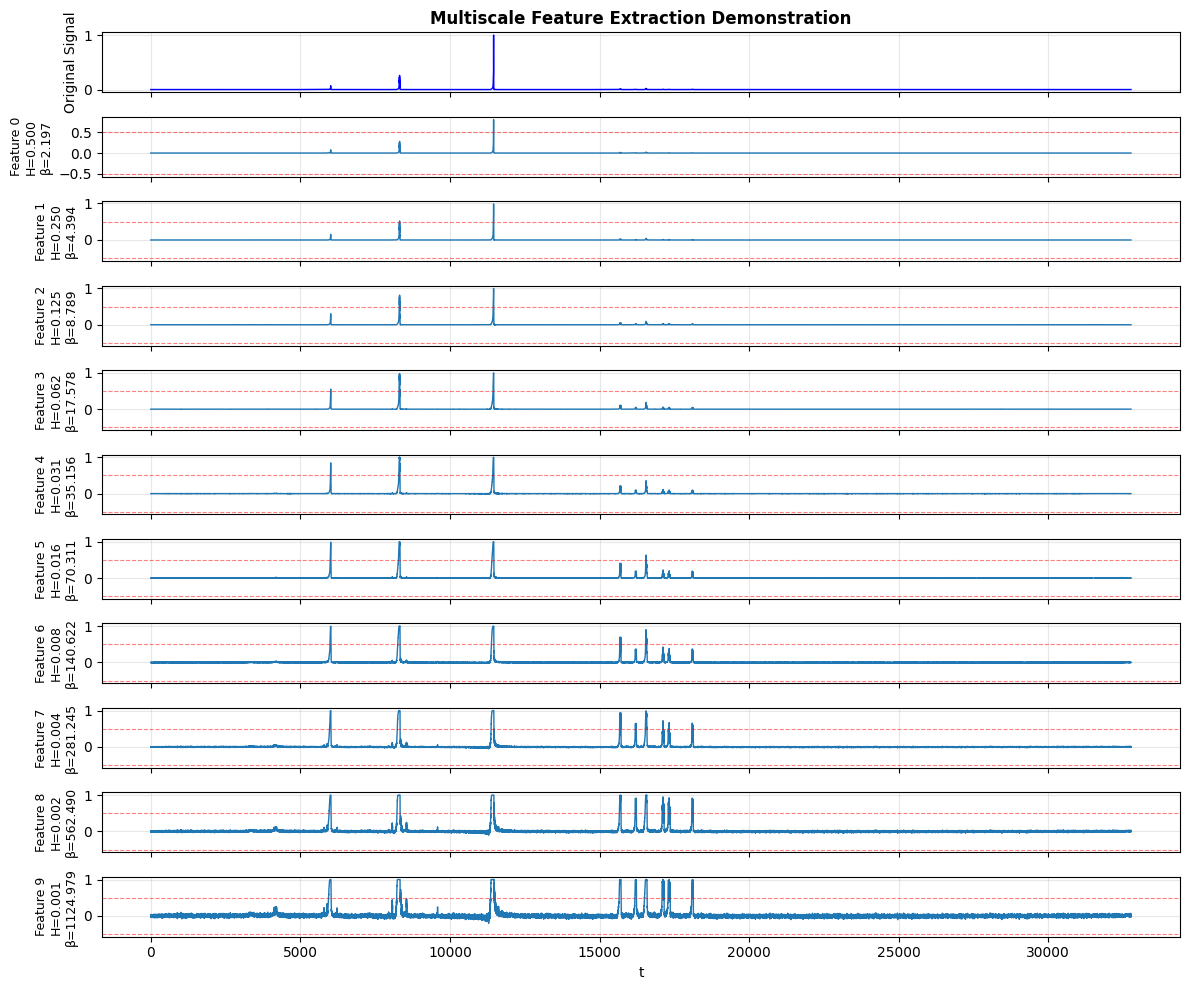


--- Verification ---
Feature 0: 2*sigmoid(β_0 * H_0) - 1 = 0.500000 (target: 0.5)
Feature 1: 2*sigmoid(β_1 * H_1) - 1 = 0.500000 (target: 0.5)
Feature 2: 2*sigmoid(β_2 * H_2) - 1 = 0.500000 (target: 0.5)
Feature 3: 2*sigmoid(β_3 * H_3) - 1 = 0.500000 (target: 0.5)
Feature 4: 2*sigmoid(β_4 * H_4) - 1 = 0.500000 (target: 0.5)
Feature 5: 2*sigmoid(β_5 * H_5) - 1 = 0.500000 (target: 0.5)
Feature 6: 2*sigmoid(β_6 * H_6) - 1 = 0.500000 (target: 0.5)
Feature 7: 2*sigmoid(β_7 * H_7) - 1 = 0.500000 (target: 0.5)
Feature 8: 2*sigmoid(β_8 * H_8) - 1 = 0.500000 (target: 0.5)
Feature 9: 2*sigmoid(β_9 * H_9) - 1 = 0.500000 (target: 0.5)


/tmp/ipykernel_659803/1057394053.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_value = 2 * torch.sigmoid(torch.tensor(extractor.betas[i] * extractor.H_values[i])) - 1


In [32]:

# Initialize feature extractor
H_0 = signal.max() / 2
lambda_scale = 0.5
k = 10

extractor = MultiscaleFeatureExtractor(H_0, lambda_scale, k)
print(extractor)

# Extract features
features = extractor.extract_features(x)
print(f"\nInput shape: {x.shape}")
print(f"Output shape: {features.shape}")

# Visualize
fig, axes = plt.subplots(k+1, 1, figsize=(12, 10), sharex=True)

# Plot original signal
axes[0].plot(x[0,0].numpy(), 'b-', linewidth=1)
axes[0].set_ylabel('Original Signal', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Multiscale Feature Extraction Demonstration', fontsize=12, fontweight='bold')

# Plot each feature scale
for i in range(k):
    axes[i+1].plot(features[0,i].numpy(), linewidth=1)
    axes[i+1].set_ylabel(f'Feature {i}\nH={extractor.H_values[i]:.3f}\nβ={extractor.betas[i]:.3f}', 
                         fontsize=9)
    axes[i+1].grid(True, alpha=0.3)
    axes[i+1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i+1].axhline(y=-0.5, color='r', linestyle='--', alpha=0.5, linewidth=0.8)

axes[-1].set_xlabel('t', fontsize=10)
plt.tight_layout()
plt.show()

# Verify that 2*sigmoid(beta_0 * H_0) - 1 = 0.5
print(f"\n--- Verification ---")
for i in range(k):
    test_value = 2 * torch.sigmoid(torch.tensor(extractor.betas[i] * extractor.H_values[i])) - 1
    print(f"Feature {i}: 2*sigmoid(β_{i} * H_{i}) - 1 = {test_value.item():.6f} (target: {extractor.target_value})")